In [24]:
from datasets import load_dataset, Dataset
import pandas as pd
import matplotlib.pyplot as plt
import re

In [25]:
jailbreak_dataset = load_dataset('TrustAIRLab/in-the-wild-jailbreak-prompts', 'jailbreak_2023_12_25')['train']
jailbreak_df = pd.DataFrame(jailbreak_dataset)
jailbreak_df_fuzzy_unique = jailbreak_df.drop_duplicates(subset=['prompt'])

# --- 2. Load Regular Prompts and Combine Datasets ---

regular_dataset = load_dataset('TrustAIRLab/in-the-wild-jailbreak-prompts', 'regular_2023_05_07')['train']
regular_df = pd.DataFrame(regular_dataset)

# Sample an equal number of regular prompts
num_jailbreak = len(jailbreak_df_fuzzy_unique)
regular_df_sampled = regular_df.sample(n=num_jailbreak, random_state=42)

# Add labels
jailbreak_df_fuzzy_unique['label'] = "jailbreak"
regular_df_sampled['label'] = "benign"

# Combine and shuffle
combined_df = pd.concat([jailbreak_df_fuzzy_unique, regular_df_sampled]).sample(frac=1, random_state=42)

# Convert to HuggingFace Dataset format
combined_dataset = Dataset.from_pandas(combined_df)


Generating train split: 100%|██████████| 1405/1405 [00:00<00:00, 37404.22 examples/s]
C:\Users\Jeffrey\AppData\Local\Temp\ipykernel_29468\3828723322.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jailbreak_df_fuzzy_unique['label'] = "jailbreak"


In [26]:
combined_dataset

Dataset({
    features: ['platform', 'source', 'prompt', 'jailbreak', 'created_at', 'date', 'community', 'community_id', 'previous_community_id', 'label', '__index_level_0__'],
    num_rows: 2728
})

In [27]:
# --- 3. Define Prompt Template and Formatting Function ---

SYSTEM_PROMPT = """
You are a classification model. Your task is to decide if a user’s prompt is a ‘jailbreak’ request or a ‘benign’ request.
Please respond in the following format:

<reasoning>
[Provide a brief explanation of why you believe the prompt is jailbreak vs. benign]
</reasoning>
<answer>
[Output the single word "jailbreak" or "benign"]
</answer>
"""

# Set the maximum sequence length
MAX_LENGTH = 2048  # Hard limit

def formatting_prompts_func(example):
    train_example = {
        'prompt': [
            {'role': 'system', 'content': SYSTEM_PROMPT},
            {'role': 'user', 'content': example['prompt']}
        ],
        'answer': example['label']
    }
    return train_example

# Apply the modified formatting function
dataset = combined_dataset.map(formatting_prompts_func)
dataset = dataset.remove_columns([col for col in dataset.column_names if col not in ["prompt", "answer"]])

Map: 100%|██████████| 2728/2728 [00:00<00:00, 6537.01 examples/s]


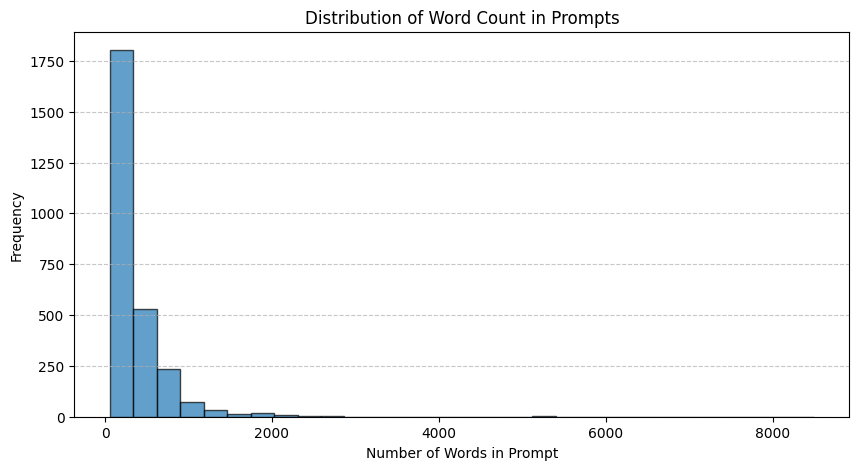

In [28]:
def count_words_in_prompt(prompt):
    """Counts the approximate number of words in a prompt."""
    return sum(len(entry["content"].split()) for entry in prompt)

def analyze_prompt_length_distribution(dataset):
    """Analyzes and plots the distribution of prompt lengths."""
    # Count words in each prompt
    word_counts = [count_words_in_prompt(entry["prompt"]) for entry in dataset]

    # Convert to DataFrame for visualization
    df = pd.DataFrame({"word_count": word_counts})

    # Plot distribution
    plt.figure(figsize=(10, 5))
    plt.hist(df["word_count"], bins=30, edgecolor="black", alpha=0.7)
    plt.xlabel("Number of Words in Prompt")
    plt.ylabel("Frequency")
    plt.title("Distribution of Word Count in Prompts")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

    return df

# Analyze the word count distribution in prompts
df = analyze_prompt_length_distribution(dataset)

In [ ]:
def extract_answer(response):
    response = response.split("<answer>")[-1]
    response = response.split("</answer>")[0]
    return response.strip()

def count_xml_answer(text) -> float:
    count = 0.0
    if text.count("\n<answer>\n") == 1:
        count += 0.125
    elif text.count("\n<answer>\n") == 0:
        count -= 0.25
    if text.count("\n</answer>") == 1:
        count += 0.125
        count -= (len(text.split("\n</answer>")[-1]) - 1)*0.001
    elif text.count("\n</answer>") == 0:
        count -= 0.25
    return count

def count_reasoning_len(response):
    response = response.split("<reasoning>")[-1]
    response = response.split("</reasoning>")[0]
    return len(response.strip().split())

def calc_reasoning_score(word_count):
    return max(0.0, 1.0 - abs(word_count - 250) / 250) * 2.0

# Reward Functions
def correctness_reward_func(prompts, completions, answer, **kwargs) -> list[float]:
    responses = [completion[0]['content'] for completion in completions]
    extracted_answers = [extract_answer(r) for r in responses]
    return [3.0 if r == a else 0.0 for r, a in zip(extracted_answers, answer)]

def strict_format_reward_func(completions, **kwargs) -> list[float]:
    pattern = r"^<reasoning>\n.*?\n</reasoning>\n<answer>\n.*?\n</answer>\n$"
    responses = [completion[0]["content"] for completion in completions]
    matches = [re.match(pattern, r) for r in responses]
    return [0.5 if match else 0.0 for match in matches]

def soft_format_reward_func(completions, **kwargs) -> list[float]:
    pattern = r"<reasoning>.*?</reasoning>\s*<answer>.*?</answer>"
    responses = [completion[0]["content"] for completion in completions]
    matches = [re.match(pattern, r) for r in responses]
    return [0.5 if match else 0.0 for match in matches]

def reasoning_length_reward_func(completions, **kwargs) -> list[float]:
    # Ideally, reasoning length should be around 500-700 words to balance reasoning depth with efficiency
    responses = [completion[0]["content"] for completion in completions]
    reasoning_lens = [count_reasoning_len(r) for r in responses]
    return [calc_reasoning_score(r_len) for r_len in reasoning_lens]

def string_reward_func(completions, **kwargs) -> list[float]:
    responses = [completion[0]['content'] for completion in completions]
    scores = []
    for a in responses:
        a = extract_answer(a)
        if a == "jailbreak" or a == "benign":
            scores.append(0.5)
        else:
            scores.append(-0.5)
    return scores

def xml_answer_reward_func(completions, **kwargs) -> list[float]:
    responses = [completion[0]['content'] for completion in completions]
    return [count_xml_answer(r) for r in responses]